# Análisis Exploratorio de Datos (EDA) y Prueba de Nodos

Este notebook realiza las visualizaciones iniciales y prueba secuencialmente todos los nodos del flujo (pipeline).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Configuracion visual
sns.set_theme(style="whitegrid")

## 1. Cargar Datos Crudos

In [2]:
asistencia_raw = pd.read_csv('../data/01_raw/asistencia.csv', encoding='latin1')
calificaciones_raw = pd.read_csv('../data/01_raw/calificaciones.csv', encoding='latin1')
estudiantes_raw = pd.read_csv('../data/01_raw/estudiantes.csv', encoding='latin1')
inscripciones_raw = pd.read_csv('../data/01_raw/inscripciones.csv', encoding='latin1')


## 2. Visualizaciones Iniciales (EDA)
A continuacion caracterizamos la data para comprender anomalías antes del procesamiento.

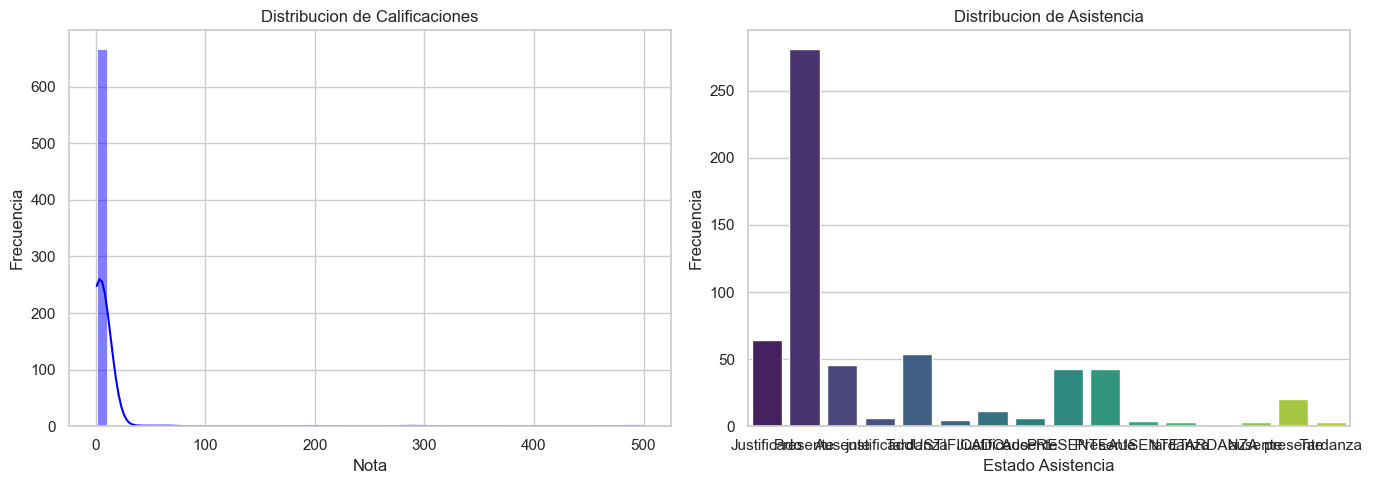

Estudiantes crudos: (360, 8)
Valores Nulos en estudiantes:
 id_estudiante       14
nombre              21
rut                 16
carrera             17
sede                26
aÃ±o_ingreso        14
email               18
estado_matricula    19
dtype: int64
Calificaciones crudas: (721, 7)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Extract numeric scores for EDA using regex
sc_clean = calificaciones_raw['nota'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
sns.histplot(sc_clean.dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribucion de Calificaciones')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frecuencia')

# Asistencia dist
sns.countplot(data=asistencia_raw, x='estado_asistencia', ax=axes[1], palette='viridis')
axes[1].set_title('Distribucion de Asistencia')
axes[1].set_xlabel('Estado Asistencia')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print("Estudiantes crudos:", estudiantes_raw.shape)
print("Valores Nulos en estudiantes:\n", estudiantes_raw.isnull().sum())
print("Calificaciones crudas:", calificaciones_raw.shape)


## 3. Nodos de Ingesta de Datos
A través del diagnostico, probamos que el nodo de ingesta reporta el baseline original.

In [4]:
import pandas as pd

def initialize_data(*datasets: pd.DataFrame) -> str:
    """Genera un diagnostico inicial de los datos ingresados."""
    report_lines = ["--- DATA INGESTION REPORT ---"]
    for i, df in enumerate(datasets):
        report_lines.append(f"\nDataset {i + 1}")
        report_lines.append(f"Shape: {df.shape}")
        report_lines.append(f"Duplicated rows: {df.duplicated().sum()}")
        nulls = df.isnull().sum()
        report_lines.append(f"Nulls:\n{nulls[nulls > 0].to_string() if nulls.sum() > 0 else '0'}")
    
    return "\n".join(report_lines)


In [5]:
report = initialize_data(asistencia_raw, calificaciones_raw, estudiantes_raw, inscripciones_raw)
print(report)

--- DATA INGESTION REPORT ---

Dataset 1
Shape: (618, 5)
Duplicated rows: 18
Nulls:
id_asistencia        28
id_inscripcion       32
fecha                34
estado_asistencia    24
tipo_clase           29

Dataset 2
Shape: (721, 7)
Duplicated rows: 21
Nulls:
id_calificacion      36
id_inscripcion       30
tipo_evaluacion      25
numero_evaluacion    36
nota                 41
ponderacion          44
fecha                33

Dataset 3
Shape: (360, 8)
Duplicated rows: 10
Nulls:
id_estudiante       14
nombre              21
rut                 16
carrera             17
sede                26
aÃ±o_ingreso        14
email               18
estado_matricula    19

Dataset 4
Shape: (927, 8)
Duplicated rows: 27
Nulls:
id_inscripcion       40
id_estudiante        37
codigo_asignatura    44
nombre_asignatura    45
seccion              47
semestre             61
aÃ±o                 50
docente              43


## 4. Nodos de Limpieza
Limpieza de strings, regex y tratamiento estandarizado.

In [6]:
import pandas as pd
import numpy as np

def clean_asistencia(df: pd.DataFrame) -> pd.DataFrame:
    # Eliminar duplicados
    df = df.drop_duplicates()
    
    # Manejo de nulos basico - forward fill u otro (aplica a series de tiempo o lógicas de negocio)
    # Por el caso base, podemos rellenar con la moda
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            mode_vals = df[col].mode()
            if len(mode_vals) > 0:
                df[col] = df[col].fillna(mode_vals[0])
            
    # Estandarizar alguna columna string si existe
    if 'estado_asistencia' in df.columns:
        df['estado_asistencia'] = df['estado_asistencia'].astype(str).str.lower().str.strip()
        
    return df

def clean_calificaciones(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates()
    
    # Si hay columna 'nota', extraemos valor numérico
    if 'nota' in df.columns:
        df['nota'] = df['nota'].astype(str).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
        df['nota'] = df['nota'].fillna(df['nota'].median())
    
    for col in df.columns:
        if df[col].isnull().sum() > 0 and col != 'nota':
            mode_vals = df[col].mode()
            if len(mode_vals) > 0:
                df[col] = df[col].fillna(mode_vals[0])
            
    # Tratamiento de outliers usando IQR
    if 'nota' in df.columns:
        Q1 = df['nota'].quantile(0.25)
        Q3 = df['nota'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Cap outliers
        df.loc[df['nota'] < lower_bound, 'nota'] = lower_bound
        df.loc[df['nota'] > upper_bound, 'nota'] = upper_bound
        
    return df

def clean_estudiantes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates()
    
    # Manejo de valores mixtos o inconsistentes, por ejemplo mayusculas en carreras o facultades
    if 'carrera' in df.columns:
        df['carrera'] = df['carrera'].astype(str).str.upper().str.strip()
        
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            # Imputar strings con modo, numeros con media
            if df[col].dtype == 'object':
                mode_vals = df[col].mode()
                if len(mode_vals) > 0:
                    df[col] = df[col].fillna(mode_vals[0])
            else:
                df[col] = df[col].fillna(df[col].median())
                
    return df

def clean_inscripciones(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates()
    
    # Estandarizar posibles fechas si existen
    for col in df.columns:
        if 'fecha' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
            
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                mode_vals = df[col].mode()
                if len(mode_vals) > 0:
                    df[col] = df[col].fillna(mode_vals[0])
            else:
                df[col] = df[col].fillna(df[col].median())
                
    return df


In [7]:
asis_int = clean_asistencia(asistencia_raw)
cal_int = clean_calificaciones(calificaciones_raw)
est_int = clean_estudiantes(estudiantes_raw)
insc_int = clean_inscripciones(inscripciones_raw)
print('Limpieza completada')

Limpieza completada


## 5. Nodos de Transformación
Pivot tables y merge integral para formar el dataset final para ML.

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

def transform_data(asistencia: pd.DataFrame, calificaciones: pd.DataFrame, estudiantes: pd.DataFrame, inscripciones: pd.DataFrame) -> pd.DataFrame:
    # 1. Agrupar calificaciones por id_inscripcion
    if 'id_inscripcion' in calificaciones.columns and 'nota' in calificaciones.columns:
        calificaciones_agg = calificaciones.groupby('id_inscripcion', as_index=False)['nota'].mean()
    else:
        calificaciones_agg = calificaciones

    # 2. Unir inscripciones con calificaciones
    if 'id_inscripcion' in inscripciones.columns and 'id_inscripcion' in calificaciones_agg.columns:
        insc_cal = pd.merge(inscripciones, calificaciones_agg, on='id_inscripcion', how='left')
    else:
        insc_cal = inscripciones

    # 3. Pivot table para la rubrica: convertir notas de asignaturas en columnas por estudiante
    if 'id_estudiante' in insc_cal.columns and 'nombre_asignatura' in insc_cal.columns and 'nota' in insc_cal.columns:
        pivot_notas = insc_cal.pivot_table(
            index='id_estudiante', 
            columns='nombre_asignatura', 
            values='nota', 
            aggfunc='mean'
        ).fillna(0).reset_index()
    else:
        pivot_notas = pd.DataFrame()

    # 4. Join final con Estudiantes
    merged = estudiantes
    if 'id_estudiante' in pivot_notas.columns:
        merged = pd.merge(merged, pivot_notas, on='id_estudiante', how='left')

    # Feature Engineering Avanzado: Indice de rendimiento (Promedio general)
    if 'id_estudiante' in insc_cal.columns and 'nota' in insc_cal.columns:
        promedio = insc_cal.groupby('id_estudiante', as_index=False)['nota'].mean().rename(columns={'nota': 'indice_rendimiento'})
        merged = pd.merge(merged, promedio, on='id_estudiante', how='left')

    # 5. Múltiples imputaciones y Rellenar nulos
    for col in merged.columns:
        if merged[col].dtype == 'object':
            mode_vals = merged[col].mode()
            merged[col] = merged[col].fillna(mode_vals[0] if not mode_vals.empty else 'Desconocido')
        else:
            merged[col] = merged[col].fillna(0)

    # 6. Codificacion de categoricas
    le = LabelEncoder()
    cat_columns = merged.select_dtypes(include=['object']).columns
    for col in cat_columns:
        merged[f"{col}_encoded"] = le.fit_transform(merged[col].astype(str))
        
    # 7. Normalizacion
    scaler = StandardScaler()
    num_columns = merged.select_dtypes(include=['float64', 'int64']).columns
    num_columns = [col for col in num_columns if col != 'id_estudiante']
    if len(num_columns) > 0:
        merged[num_columns] = scaler.fit_transform(merged[num_columns])
        
    return merged


In [9]:
dataset_integrado = transform_data(asis_int, cal_int, est_int, insc_int)
display(dataset_integrado.head())

,id_estudiante,nombre,rut,carrera,sede,aÃ±o_ingreso,email,estado_matricula,Algoritmos,Base de Datos,...,ÃTICA,Ãtica,Ã©tica,indice_rendimiento,nombre_encoded,rut_encoded,carrera_encoded,sede_encoded,email_encoded,estado_matricula_encoded
0,1.0,Ignacio Espinoza Vergara,23003953-7,ENFERMERÃ­A,Sede Sur,-0.859890,ignacio.espinoza@outlook.com,Regular,-0.091936,-0.088961,...,-0.092907,-0.260118,-0.053529,-0.439103,-0.081617,0.688302,-0.087174,0.643893,-0.078261,-2.047076
1,176.0,Carlos Gatica Medina,10028401-8,ADMINISTRACIÃ³N,Santiago Centro,1.001727,carlos.gatica@outlook.com,REGULAR,-0.091936,-0.088961,...,-0.092907,-0.260118,-0.053529,-1.293853,-0.871786,-1.590873,-1.272067,-0.843648,-0.876592,0.289987
2,3.0,Camila Aguilera LÃ³pez,16824501-5,PSICOLOGÃ­A,Sede Norte,-0.239351,camila.aguilera@gmail.com,regular,-0.091936,-0.088961,...,-0.092907,-0.260118,-0.053529,1.067955,-0.931799,-0.466214,1.690165,-0.099878,-0.930533,1.625451
3,4.0,MarÃ­a Rojas Vergara,20713487-8,ARQUITECTURA,ConcepciÃ³n,-0.239351,marÃ­a.rojas@outlook.com,EGRESADO,8.353362,-0.088961,...,-0.092907,-0.260118,-0.053529,0.719308,0.758562,0.310099,-0.975844,-1.587419,0.741646,-0.377746
4,5.0,Fernanda MartÃ­nez Flores,16300007-6,ARQUITECTURA,ViÃ±a del Mar,1.001727,alejandra.tapia@outlook.com,Congelada,-0.091936,-0.088961,...,-0.092907,-0.260118,-0.053529,-1.293853,-0.261656,-0.565742,-0.975844,1.387663,-1.469946,-1.379344


## 6. Nodos de Validación

In [10]:
import pandas as pd

def validate_data(df_integrado: pd.DataFrame) -> str:
    report_lines = ["--- DATA VALIDATION REPORT ---"]
    report_lines.append(f"Shape of integrated dataset: {df_integrado.shape}")
    
    # Validar que no hay nulos (o documentar si quedaron)
    nulls = df_integrado.isnull().sum()
    total_nulls = nulls.sum()
    report_lines.append(f"Total null values in integrated dataset: {total_nulls}")
    
    if total_nulls > 0:
        report_lines.append(f"Columns with nulls:\n{nulls[nulls > 0].to_string()}")
        
    # Verificar codificacion y escalado
    dtypes_counts = df_integrado.dtypes.value_counts()
    report_lines.append(f"\nData Types summary:\n{dtypes_counts.to_string()}")
    
    if 'indice_rendimiento' in df_integrado.columns:
        report_lines.append(f"\nIndice de rendimiento derivation succeeded. Mean: {df_integrado['indice_rendimiento'].mean():.2f}")
        
    return "\n".join(report_lines)


In [11]:
val_report = validate_data(dataset_integrado)
print(val_report)

--- DATA VALIDATION REPORT ---
Shape of integrated dataset: (350, 60)
Total null values in integrated dataset: 0

Data Types summary:
float64    54
object      6

Indice de rendimiento derivation succeeded. Mean: -0.00
